## CONOIL STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

conoil=pd.read_csv('../stock_data/conoil.csv') ## so it can be small letter. This is cool.
conoil=conoil.drop(columns=['high_price','low_price'])
conoil.rename(columns={'trade_date':'date'},inplace=True)
conoil['date']=pd.to_datetime(conoil['date'])
conoil['month']=conoil['date'].dt.month
conoil['quarter']=conoil['date'].dt.quarter
conoil['year']=conoil['date'].dt.year

conoil

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42850,CONOIL,2017-01-03,37.48,37.48,62092,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43410,CONOIL,2017-01-04,37.48,37.48,39825,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43520,CONOIL,2017-01-05,37.48,37.48,90099,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43630,CONOIL,2017-01-06,37.48,37.48,112601,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43720,CONOIL,2017-01-09,37.48,37.48,249765,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298044,CONOIL,2026-07-13,210.00,210.00,51008,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298482,CONOIL,2026-07-14,210.00,210.00,27103,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298920,CONOIL,2026-07-15,210.00,210.00,66493,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299358,CONOIL,2026-07-16,210.00,210.00,17977,2026-07-16T15:10:03.113936+00:00,7,3,2026


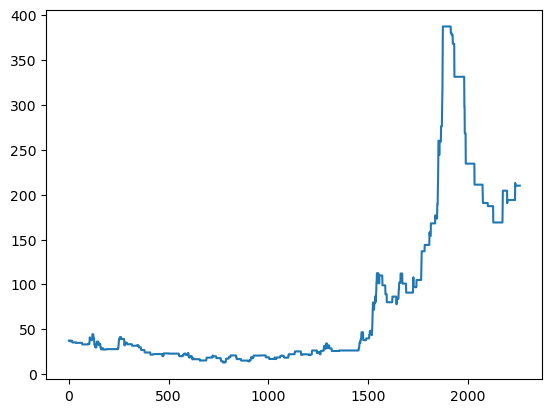

In [2]:
import matplotlib.pyplot as plt

plt.plot(conoil['close_price'])
plt.show()

In [3]:
conoil_end_month_df = (
    conoil
    .sort_values("date")
    .groupby(conoil["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

conoil_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45420,CONOIL,2017-01-31,35.49,35.49,2369,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47243,CONOIL,2017-02-28,35.00,35.00,1030,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49359,CONOIL,2017-03-31,35.00,35.00,72176,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51186,CONOIL,2017-04-28,33.25,33.25,9104,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53109,CONOIL,2017-05-31,33.90,33.90,3386831,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35280,CONOIL,2026-03-31,204.40,204.40,48673,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281107,CONOIL,2026-04-30,194.00,194.00,148778,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284173,CONOIL,2026-05-29,194.00,194.00,40074,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294102,CONOIL,2026-06-30,210.00,210.00,16038,2026-06-30T15:10:03.08168+00:00,6,2,2026


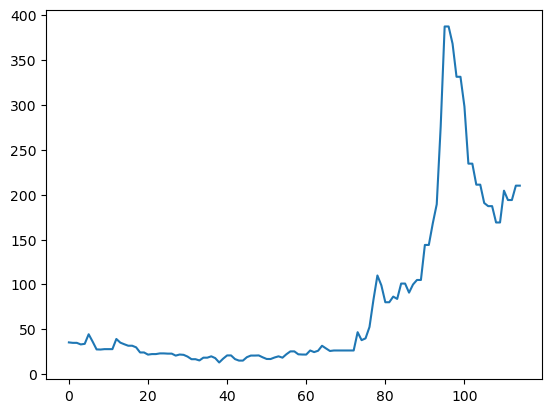

In [4]:
plt.plot(conoil_end_month_df['close_price'])
plt.show()

In [5]:
conoil_end_month_df['returns']=conoil_end_month_df['close_price'].pct_change()*100
conoil_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45420,CONOIL,2017-01-31,35.49,35.49,2369,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47243,CONOIL,2017-02-28,35.00,35.00,1030,2026-04-08T02:44:45.006295+00:00,2,1,2017,-1.380671
2,49359,CONOIL,2017-03-31,35.00,35.00,72176,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51186,CONOIL,2017-04-28,33.25,33.25,9104,2026-04-08T02:51:55.619599+00:00,4,2,2017,-5.000000
4,53109,CONOIL,2017-05-31,33.90,33.90,3386831,2026-04-08T02:52:57.421655+00:00,5,2,2017,1.954887
...,...,...,...,...,...,...,...,...,...,...,...
110,35280,CONOIL,2026-03-31,204.40,204.40,48673,2026-03-31T15:00:02.085058+00:00,3,1,2026,20.946746
111,281107,CONOIL,2026-04-30,194.00,194.00,148778,2026-04-30T15:00:02.170664+00:00,4,2,2026,-5.088063
112,284173,CONOIL,2026-05-29,194.00,194.00,40074,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294102,CONOIL,2026-06-30,210.00,210.00,16038,2026-06-30T15:10:03.08168+00:00,6,2,2026,8.247423


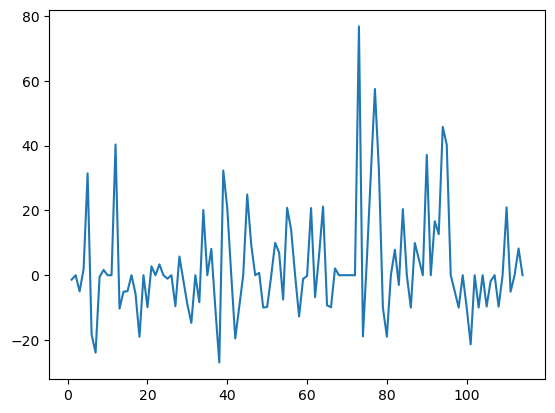

In [6]:
plt.plot(conoil_end_month_df['returns'])
plt.show()

(-9.192122741999192, 2.109521781606329e-15, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 842.0989899374109)
stationary


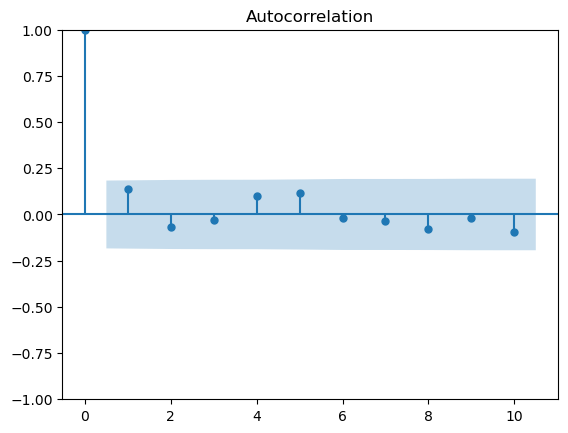

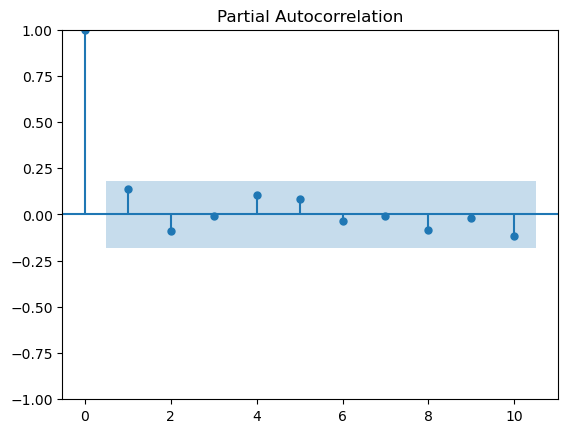

In [8]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(conoil_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(conoil_end_month_df['returns'].dropna(), lags=10)
plot_pacf(conoil_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=conoil_end_month_df['close_price'][:-10]
test=conoil_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -191.74970799658212]
[0, 0, 0, 0, 0, 1, -19.310763370821412]
[0, 0, 0, 0, 0, 2, -134.2334446512648]
[0, 0, 0, 0, 1, 0, -94.13381464903408]
[0, 0, 0, 0, 1, 1, -356.98329510889766]
[0, 0, 0, 0, 1, 2, -509.244636690343]
[0, 0, 0, 0, 2, 0, -631.2027287621374]
[0, 0, 0, 0, 2, 1, -873.6881338977022]
[0, 0, 0, 0, 2, 2, -1160.1188590170732]
[0, 0, 0, 1, 0, 0, -55.59733728288593]
[0, 0, 0, 1, 0, 1, -242.61968863152137]
[0, 0, 0, 1, 0, 2, -345.29908524488167]
[0, 0, 0, 1, 1, 0, -474.4908360216583]
[0, 0, 0, 1, 1, 1, -627.6646242718325]
[0, 0, 0, 1, 1, 2, -661.2690105716011]
[0, 0, 0, 1, 2, 0, -992.2631033234384]
[0, 0, 0, 1, 2, 1, -984.0795505953507]
[0, 0, 0, 1, 2, 2, -985.6620074442666]
[0, 0, 0, 2, 0, 0, -286.91174981739175]
[0, 0, 0, 2, 0, 1, -385.91496381607055]
[0, 0, 0, 2, 0, 2, -404.4471410462827]
[0, 0, 0, 2, 1, 0, -663.6792457385066]
[0, 0, 0, 2, 1, 1, -666.1797226332887]
[0, 0, 0, 2, 1, 2, -665.0934412968413]
[0, 0, 0, 2, 2, 0, -984.006408339135]
[0, 0, 0, 2, 2, 1, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
8,0,0,0,0,2,2,-1160.118859
15,0,0,0,1,2,0,-992.263103
26,0,0,0,2,2,2,-987.195870
17,0,0,0,1,2,2,-985.662007
25,0,0,0,2,2,1,-985.291993
...,...,...,...,...,...,...,...
270,1,0,1,0,0,0,-1.735243
135,0,1,2,0,0,0,-1.728021
378,1,1,2,0,0,0,-1.573945
243,1,0,0,0,0,0,-1.044270


No good model. Lets use the returns.

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=conoil_end_month_df['returns'].dropna()[:-10]
test=conoil_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.001150916640397126]
[0, 0, 0, 0, 0, 1, -0.4567410291906937]
[0, 0, 0, 0, 0, 2, -0.3967785580992278]
[0, 0, 0, 0, 1, 0, -7.946399822241535]
[0, 0, 0, 0, 1, 1, -1.8959067733257857]
[0, 0, 0, 0, 1, 2, -1.9822779828040886]
[0, 0, 0, 0, 2, 0, -28.49671310014207]
[0, 0, 0, 0, 2, 1, -10.323374668022298]
[0, 0, 0, 0, 2, 2, -5.561575097792949]
[0, 0, 0, 1, 0, 0, -0.443474920714396]
[0, 0, 0, 1, 0, 1, -0.4039040691646778]
[0, 0, 0, 1, 0, 2, -0.3978173439098198]
[0, 0, 0, 1, 1, 0, -4.788099132100698]
[0, 0, 0, 1, 1, 1, -1.9325985656197133]
[0, 0, 0, 1, 1, 2, -1.9447057573017479]
[0, 0, 0, 1, 2, 0, -24.555591637470478]
[0, 0, 0, 1, 2, 1, -7.622734086566556]
[0, 0, 0, 1, 2, 2, -5.354359784512575]
[0, 0, 0, 2, 0, 0, -0.4111482002747633]
[0, 0, 0, 2, 0, 1, -0.39701473019865574]
[0, 0, 0, 2, 0, 2, -1.3708584675679463]
[0, 0, 0, 2, 1, 0, -4.238404328930836]
[0, 0, 0, 2, 1, 1, -1.9847522896484855]
[0, 0, 0, 2, 1, 2, -1.9808590813006366]
[0, 0, 0, 2, 2, 0, -11.622449124476724]
[0, 0

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-954.950516
654,2,2,0,0,2,0,-473.830176
411,1,2,0,0,2,0,-222.704188
177,0,2,0,1,2,0,-152.692708
429,1,2,0,2,2,0,-149.010572
...,...,...,...,...,...,...,...
27,0,0,1,0,0,0,-0.010508
243,1,0,0,0,0,0,-0.001151
81,0,1,0,0,0,0,-0.001151
0,0,0,0,0,0,0,-0.001151


We will visit it.

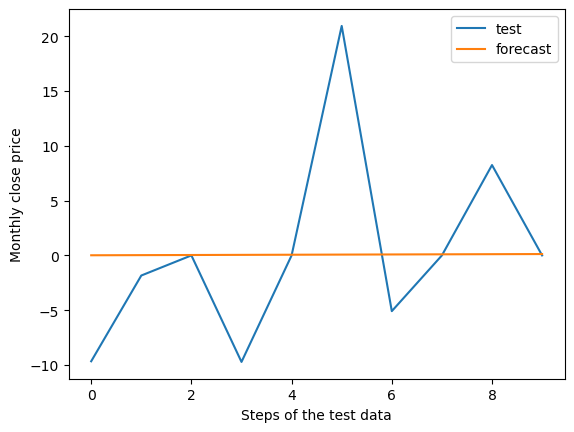

r2_score:  0.002606314145499833
rmse:  8.49255043271411
description:  count    114.000000
mean       2.708039
std       16.308282
min      -26.944444
25%       -7.323113
50%        0.000000
75%        5.996964
max       76.792453
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=conoil_end_month_df['returns'].dropna()[:-10]
y_test=conoil_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', conoil_end_month_df.returns.dropna().describe())

Very poor. Nothing was learned.